In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
#load dataset
df = pd.read_csv(r"C:\Users\Acer\Downloads\Sleep_health_and_lifestyle_dataset.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
#display dataset
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
#dataset informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
df.shape

(374, 13)

In [6]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [7]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [8]:
df["Sleep Disorder"].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [9]:
#checking missing value
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [10]:
df=df.dropna(subset=['Sleep Disorder'])

In [11]:
df['Sleep Disorder'].isnull().sum()

np.int64(0)

In [12]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


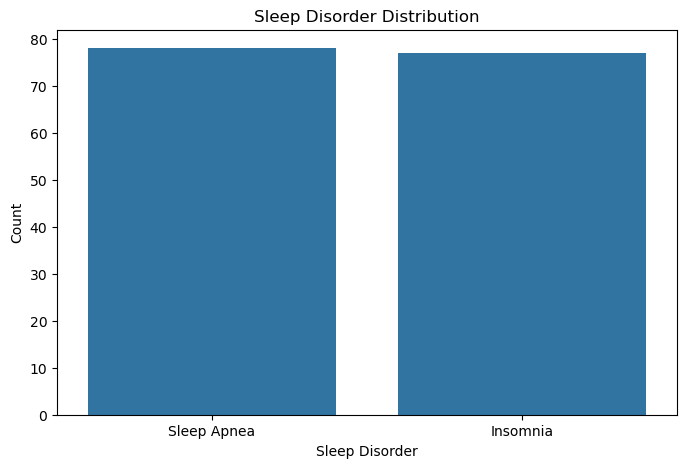

In [13]:
# eda
# ============================================
# Sleep Disorder Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Sleep Disorder")

plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")

plt.show()

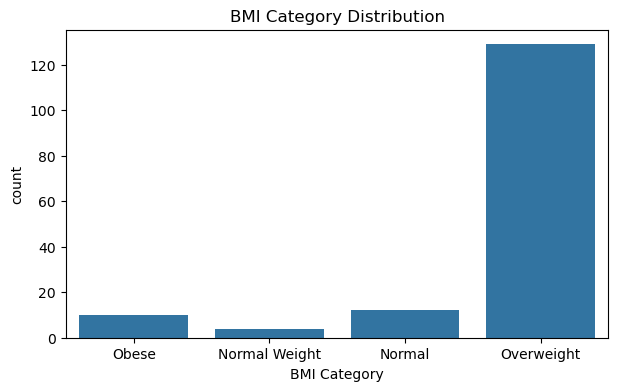

In [14]:
# ============================================
# BMI Category Distribution
# ============================================

plt.figure(figsize=(7,4))

sns.countplot(data=df, x="BMI Category")

plt.title("BMI Category Distribution")

plt.show()

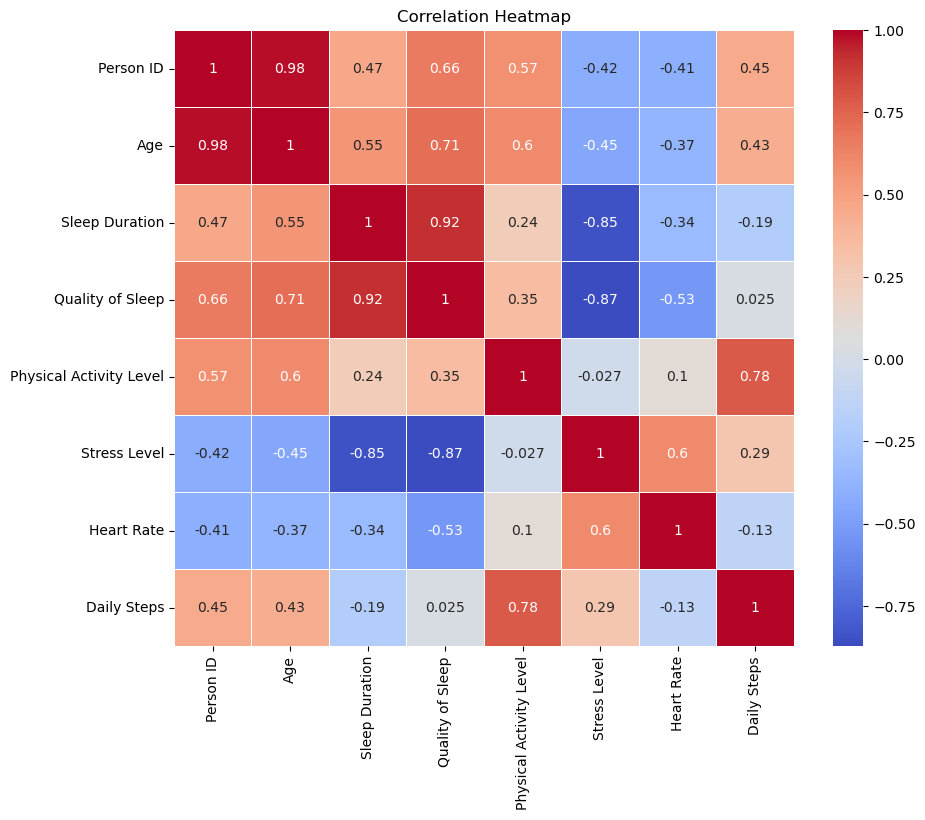

In [15]:
# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
# ============================================
# Drop Unnecessary Columns
# ============================================

df.drop("Person ID", axis=1, inplace=True)

df.head()

C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\2280958975.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop("Person ID", axis=1, inplace=True)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea


In [17]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Occupation', 'BMI Category', 'Blood Pressure',
       'Sleep Disorder'],
      dtype='object')

In [18]:
from sklearn.preprocessing import LabelEncoder
le_sleep = LabelEncoder()
df["Sleep Disorder"]=le_sleep.fit_transform(df["Sleep Disorder"])

C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\1674660152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sleep Disorder"]=le_sleep.fit_transform(df["Sleep Disorder"])


In [19]:
mapping=dict(zip(le_sleep.classes_,le_sleep.transform(le_sleep.classes_)))
print(mapping)

{'Insomnia': np.int64(0), 'Sleep Apnea': np.int64(1)}


In [20]:
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,1
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,1
5,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,0
6,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,0
16,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,1
370,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,1
371,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,1
372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,1


In [21]:
# Split Blood Pressure into two columns
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

# Convert to integer
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

# Drop original column
df.drop('Blood Pressure', axis=1, inplace=True)

# Check result
df.head()

C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\4141645253.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\4141645253.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\4141645253.py:5: SettingWithCopyWarning: 
A value is trying to be

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
5,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,0,140,90
6,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,0,140,90
16,Female,29,Nurse,6.5,5,40,7,Normal Weight,80,4000,1,132,87


In [22]:
df.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [23]:
gen_map={"Male":0,"Female":1}
df["Gender"]=df["Gender"].replace(gen_map)
df

C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\1637153297.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"]=df["Gender"].replace(gen_map)
C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\1637153297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Gender"]=df["Gender"].replace(gen_map)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
3,0,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
4,0,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
5,0,28,Software Engineer,5.9,4,30,8,Obese,85,3000,0,140,90
6,0,29,Teacher,6.3,6,40,7,Obese,82,3500,0,140,90
16,1,29,Nurse,6.5,5,40,7,Normal Weight,80,4000,1,132,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,1,59,Nurse,8.1,9,75,3,Overweight,68,7000,1,140,95
370,1,59,Nurse,8.0,9,75,3,Overweight,68,7000,1,140,95
371,1,59,Nurse,8.1,9,75,3,Overweight,68,7000,1,140,95
372,1,59,Nurse,8.1,9,75,3,Overweight,68,7000,1,140,95


In [24]:
df.Occupation.unique()

array(['Sales Representative', 'Software Engineer', 'Teacher', 'Nurse',
       'Doctor', 'Scientist', 'Lawyer', 'Accountant', 'Engineer',
       'Salesperson'], dtype=object)

In [25]:
occ_map={'Sales Representative':0, 'Software Engineer':1, 'Teacher':2, 'Nurse':3,'Doctor':4, 'Scientist':5, 'Lawyer':6, 'Accountant':7, 'Engineer':8,
         'Salesperson':9}
df["Occupation"]=df["Occupation"].replace(occ_map)
df


C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\3272702312.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Occupation"]=df["Occupation"].replace(occ_map)
C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\3272702312.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Occupation"]=df["Occupation"].replace(occ_map)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
3,0,28,0,5.9,4,30,8,Obese,85,3000,1,140,90
4,0,28,0,5.9,4,30,8,Obese,85,3000,1,140,90
5,0,28,1,5.9,4,30,8,Obese,85,3000,0,140,90
6,0,29,2,6.3,6,40,7,Obese,82,3500,0,140,90
16,1,29,3,6.5,5,40,7,Normal Weight,80,4000,1,132,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,1,59,3,8.1,9,75,3,Overweight,68,7000,1,140,95
370,1,59,3,8.0,9,75,3,Overweight,68,7000,1,140,95
371,1,59,3,8.1,9,75,3,Overweight,68,7000,1,140,95
372,1,59,3,8.1,9,75,3,Overweight,68,7000,1,140,95


In [26]:
df["BMI Category"].unique()

array(['Obese', 'Normal Weight', 'Normal', 'Overweight'], dtype=object)

In [27]:
bmi_map={'Obese':0, 'Normal Weight':1, 'Normal':2, 'Overweight':3}
df["BMI Category"]=df["BMI Category"].replace(bmi_map)
df

C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\993232839.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["BMI Category"]=df["BMI Category"].replace(bmi_map)
C:\Users\Acer\AppData\Local\Temp\ipykernel_12536\993232839.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["BMI Category"]=df["BMI Category"].replace(bmi_map)


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
3,0,28,0,5.9,4,30,8,0,85,3000,1,140,90
4,0,28,0,5.9,4,30,8,0,85,3000,1,140,90
5,0,28,1,5.9,4,30,8,0,85,3000,0,140,90
6,0,29,2,6.3,6,40,7,0,82,3500,0,140,90
16,1,29,3,6.5,5,40,7,1,80,4000,1,132,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,1,59,3,8.1,9,75,3,3,68,7000,1,140,95
370,1,59,3,8.0,9,75,3,3,68,7000,1,140,95
371,1,59,3,8.1,9,75,3,3,68,7000,1,140,95
372,1,59,3,8.1,9,75,3,3,68,7000,1,140,95


In [28]:
# ============================================
# Features and Target
# ============================================

X = df.drop("Sleep Disorder", axis=1)

y = df["Sleep Disorder"]

In [29]:
# ============================================
# Feature Scaling
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [30]:
# ============================================
# Train Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [31]:
print(y_train.value_counts())

Sleep Disorder
0    63
1    61
Name: count, dtype: int64


In [32]:
# ============================================
# Models
# ============================================

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}
# ============================================
# Model Training and Evaluation
# ============================================

best_model = None
best_model_name = ""
best_score = 0

results = []

for name, model in models.items():

    print("\n" + "="*60)
    print(f"Model : {name}")
    print("="*60)

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print("Training Accuracy :", round(train_score*100,2),"%")
    print("Testing Accuracy  :", round(test_score*100,2),"%")

    # Save Results
    results.append([name, train_score, test_score])

    # Best Model
    if test_score > best_score:
        best_score = test_score
        best_model = model
        best_model_name = name

    # Confusion Matrix
    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_test_pred))

    # Classification Report
    print("\nClassification Report")

    print(classification_report(y_test, y_test_pred))


Model : Logistic Regression
Training Accuracy : 92.74 %
Testing Accuracy  : 80.65 %

Confusion Matrix
[[11  3]
 [ 3 14]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        14
           1       0.82      0.82      0.82        17

    accuracy                           0.81        31
   macro avg       0.80      0.80      0.80        31
weighted avg       0.81      0.81      0.81        31


Model : Decision Tree
Training Accuracy : 95.97 %
Testing Accuracy  : 83.87 %

Confusion Matrix
[[12  2]
 [ 3 14]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        14
           1       0.88      0.82      0.85        17

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31


Model : Random Forest
Training Accuracy : 95.97 %
Testing Acc

In [33]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


Gender
[0 1]

Age
[28 29 30 31 33 34 35 36 38 39 41 42 43 44 45 48 49 50 51 52 53 55 57 58
 59]

Occupation
[0 1 2 3 4 5 6 7 8 9]

Sleep Duration
[5.9 6.3 6.5 6.  6.4 7.7 5.8 7.4 7.2 6.6 7.1 7.6 6.8 6.7 7.8 7.3 6.1 6.2
 8.1 8.3 8.2 8. ]

Quality of Sleep
[4 6 5 7 8 9]

Physical Activity Level
[30 40 35 75 32 60 90 45 65 85]

Stress Level
[8 7 6 5 4 3]

BMI Category
[0 1 2 3]

Heart Rate
[85 82 80 70 78 72 81 84 68 74 65 83 75 86]

Daily Steps
[ 3000  3500  4000  8000  4100  5000  5200  3300  7000  4800  6000 10000
  3700]

Sleep Disorder
[1 0]

Systolic_BP
[140 132 120 130 125 131 135 115 129 142 139]

Diastolic_BP
[90 87 80 86 88 75 84 85 92 95 91]


In [34]:
# ============================================
# Model Comparison
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy"
    ]
)



results_df = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

results_df


,Model,Train Accuracy,Test Accuracy
2,Random Forest,0.959677,0.870968
4,K-Nearest Neighbors,0.911290,0.870968
1,Decision Tree,0.959677,0.838710
0,Logistic Regression,0.927419,0.806452
3,Support Vector Machine,0.935484,0.806452


In [35]:
from sklearn.svm import SVC

best_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("Best Model : Support Vector Machine")
print("Test Accuracy :", round(accuracy*100, 2), "%")
print("="*50)

Best Model : Support Vector Machine
Test Accuracy : 80.65 %


In [36]:
# ============================================
# Hyperparameter Grid for SVM
# ============================================

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# ============================================
# GridSearchCV
# ============================================

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

best_svm = grid_search.best_estimator_

print(best_svm)

y_pred = best_svm.predict(X_test)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:
{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross Validation Accuracy:
0.8956666666666667
SVC(C=0.1, gamma=0.01)


In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy :", round(accuracy*100,2),"%")

Test Accuracy : 80.65 %


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82        14
           1       1.00      0.65      0.79        17

    accuracy                           0.81        31
   macro avg       0.85      0.82      0.80        31
weighted avg       0.86      0.81      0.80        31



In [61]:
print("="*50)
print("Sleep Disorder Prediction System")
print("="*50)

print("gender : male=0 ,female=1")
Gender = input("Gender : ").strip()
Gender=gen_map.get(Gender,0)

Age = int(input("Age: "))

print("occupation: Sales Representative,Software Engineer,Teacher,Nurse, Doctor, Scientist, Lawyer, Accountant, Engineer,Salesperson")
Occupation=input("occupation :").strip()
Occupation=occ_map.get(Occupation,0)

Sleep_Duration = float(input("Sleep Duration: "))
Quality_of_Sleep = input("Quality of Sleep (1-10)")
Physical_Activity_Level = int( input("Physical Activity Level: "))
Stress_Level = int(input("Stress Level (1-10): "))

print("bmi catogeory: 'Obese', 'Normal Weight', 'Normal', 'Overweight'")
BMI_Category = input("BMI Category : ").strip()
BMI_Category=bmi_map.get(BMI_Category,0)

Heart_Rate =int( input("Blood Pressure : "))
Daily_steps = int(input(" Daily Steps: "))
Systolic_BP =int(input("systolic bp:"))
Diastolic_BP = int(input("diastolic bp:"))


user_input = [[
    Gender,
    Age,
    Occupation,
    Sleep_Duration,
    Quality_of_Sleep,
    Physical_Activity_Level,
    Stress_Level,
    BMI_Category,
    Heart_Rate,
    Daily_steps,
    Systolic_BP,
    Diastolic_BP
]]

# Scale Input
user_input = scaler.transform(user_input)

# Predict
prediction = best_svm.predict(user_input)

# Convert numeric prediction back to category
predicted_label = le_sleep.inverse_transform(prediction)

print("\nPredicted Sleep Disorder :", predicted_label[0])

Sleep Disorder Prediction System
gender : male=0 ,female=1


Gender :  1
Age:  23


occupation: Sales Representative,Software Engineer,Teacher,Nurse, Doctor, Scientist, Lawyer, Accountant, Engineer,Salesperson


occupation :  Lawyer
Sleep Duration:  8
Quality of Sleep (1-10) 6
Physical Activity Level:  7
Stress Level (1-10):  9


bmi catogeory: 'Obese', 'Normal Weight', 'Normal', 'Overweight'


BMI Category :  Normal
Blood Pressure :  400
 Daily Steps:  4000
systolic bp: 120
diastolic bp: 30



Predicted Sleep Disorder : Sleep Apnea


C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [62]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("Problem Type       : Classification")
print("Best Model         : svm")
print("Final Accuracy     :", round(accuracy*100,2), "%")
print("SVM : Completed")
print("Prediction System  : Successfully Implemented")

print("="*60)             #conclusion

PROJECT SUMMARY
Problem Type       : Classification
Best Model         : svm
Final Accuracy     : 80.65 %
SVM : Completed
Prediction System  : Successfully Implemented


# saving model

In [ ]:
import pickle

# Save the scaler
with open('sleep_health_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the model
with open('sleep health_model.pkl', 'wb') as f:
    pickle.dump(model, f)
